In [382]:
import pandas as pd
import numpy as np
import nflreadpy as nfl

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', None)


# 1. LOAD RAW NFL DATA

# player stats
player = nfl.load_player_stats(
    seasons=range(2018, 2026)
).to_pandas()

player = player[player["season_type"] == "REG"]

# team game stats (off + def)
team_stats = nfl.load_team_stats(
    seasons=range(2018, 2026)
).to_pandas()

# schedules
schedule_df = nfl.load_schedules(
    seasons=range(2018, 2026)
).to_pandas()

print("Loaded successfully:")
print(" player:", player.shape)
print(" team_stats:", team_stats.shape)
print(" schedule:", schedule_df.shape)


Loaded successfully:
 player: (135429, 114)
 team_stats: (4270, 102)
 schedule: (2214, 46)


In [383]:
# 2. BUILD BASE QB DATASET

# filter QB rows
qbs = player[player['position'] == 'QB'].copy()

# regular season only
qbs = qbs[qbs['season_type'] == 'REG']

# remove low-attempt games
qbs = qbs[qbs['attempts'].fillna(0) >= 10]

# going to use 2018+
qbs = qbs[qbs['season'] >= 2018]

# relevant cols
qb_cols = [
    'player_id',
    'player_name',
    'season',
    'week',
    'team',
    'opponent_team',

    # passing
    'attempts',
    'completions',
    'passing_yards',
    'passing_tds',
    'passing_interceptions',
    'passing_air_yards',
    'passing_yards_after_catch',
    'passing_first_downs',
    'passing_epa',
    'passing_cpoe',

    # pressure
    'sacks_suffered',
    'sack_yards_lost',

    # rushing
    'carries',
    'rushing_yards',
    'rushing_tds',
    'rushing_epa',
]

qbs = qbs[qb_cols]

qbs = qbs.sort_values(['player_id', 'season', 'week'])

In [384]:
# 3. MERGE SINGLE-GAME OPPONENT DEFENSIVE STATS

defense_cols = [
    'season', 'week', 'team',
    'def_sacks',
    'def_qb_hits',
    'def_interceptions',
    'def_pass_defended',
    'def_tackles_for_loss',
    'def_safeties',
    'def_fumbles',
    'penalties',
    'penalty_yards'
]

# extract def. stats
defense = team_stats[defense_cols].copy()

# prefix def. cols w/ opp_
defense = defense.rename(
    columns=lambda c: f"opp_{c}" if c not in ['season', 'week', 'team'] else c
)

# merge onto qb dataset
qbs_merged = qbs.merge(
    defense,
    left_on=['season', 'week', 'opponent_team'],
    right_on=['season', 'week', 'team'],
    how='left'
)

# clean up
qbs_merged = qbs_merged.drop(columns=['team_y'])
qbs_merged = qbs_merged.rename(columns={'team_x': 'team'})

In [385]:
# 4. ADD OPPONENT DEFENSIVE ROLLING FEATURES

defense_raw = team_stats[defense_cols].copy()
defense_raw = defense_raw.sort_values(['team', 'season', 'week'])

def_stats = [
    'def_sacks',
    'def_qb_hits',
    'def_interceptions',
    'def_pass_defended',
    'def_tackles_for_loss',
    'def_fumbles',
    'penalties',
    'penalty_yards'
]

for stat in def_stats:
    # 3-game rolling avg
    defense_raw[f'{stat}_3'] = (
        defense_raw.groupby('team')[stat]
        .rolling(window=3, min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

    # 5-game
    defense_raw[f'{stat}_5'] = (
        defense_raw.groupby('team')[stat]
        .rolling(window=5, min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

    # Full season
    defense_raw[f'{stat}_season'] = (
        defense_raw.groupby(['team', 'season'])[stat]
        .expanding(min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=[0, 1], drop=True)
    )

# merge
qbs_merged = qbs_merged.merge(
    defense_raw,
    left_on=['season', 'week', 'opponent_team'],
    right_on=['season', 'week', 'team'],
    how='left',
    suffixes=("", "_defraw")
)

# drop extra team column from second merge
qbs_merged = qbs_merged.drop(columns=['team_defraw'])

# Clean up defensive columns

dup_cols = [c for c in qbs_merged.columns if c.endswith('_defraw')]
qbs_merged = qbs_merged.drop(columns=dup_cols)

raw_def_base = [
    'def_sacks',
    'def_qb_hits',
    'def_interceptions',
    'def_pass_defended',
    'def_tackles_for_loss',
    'def_safeties',
    'def_fumbles',
    'penalties',
    'penalty_yards'
]
raw_def_base = [c for c in raw_def_base if c in qbs_merged.columns]
qbs_merged = qbs_merged.drop(columns=raw_def_base)

# some renaming
rename_map = {}
for c in qbs_merged.columns:
    for stat in def_stats:
        if c.startswith(stat + '_'):
            rename_map[c] = 'opp_' + c
            break

qbs_merged = qbs_merged.rename(columns=rename_map)

In [386]:
# 5. ADD TEAM OFFENSIVE ROLLING FEATURES

team_off_stats = [
    'attempts',
    'completions',
    'passing_yards',
    'passing_tds',
    'passing_interceptions',
    'passing_epa',
    'passing_first_downs',
    'carries',
    'rushing_yards',
    'rushing_tds',
    'rushing_epa'
]

team_stats_off = team_stats[['season', 'week', 'team'] + team_off_stats].copy()
team_stats_off = team_stats_off.sort_values(['team', 'season', 'week'])

for stat in team_off_stats:
    team_stats_off[f'{stat}_3'] = (
        team_stats_off.groupby('team')[stat]
        .rolling(window=3, min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

    team_stats_off[f'{stat}_5'] = (
        team_stats_off.groupby('team')[stat]
        .rolling(window=5, min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

    team_stats_off[f'{stat}_season'] = (
        team_stats_off.groupby(['team', 'season'])[stat]
        .expanding(min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=[0, 1], drop=True)
    )

qbs_merged = qbs_merged.merge(
    team_stats_off,
    on=['season', 'week', 'team'],
    how='left'
)

rename_map = {
    # qb-level
    'attempts_x': 'qb_attempts',
    'completions_x': 'qb_completions',
    'passing_yards_x': 'qb_passing_yards',
    'passing_tds_x': 'qb_passing_tds',
    'passing_interceptions_x': 'qb_passing_int',
    'passing_epa_x': 'qb_passing_epa',
    'passing_first_downs_x': 'qb_passing_first_downs',
    'carries_x': 'qb_carries',
    'rushing_yards_x': 'qb_rushing_yards',
    'rushing_tds_x': 'qb_rushing_tds',
    'rushing_epa_x': 'qb_rushing_epa',

    # team-level
    'attempts_y': 'team_attempts',
    'completions_y': 'team_completions',
    'passing_yards_y': 'team_passing_yards',
    'passing_tds_y': 'team_passing_tds',
    'passing_interceptions_y': 'team_passing_int',
    'passing_epa_y': 'team_passing_epa',
    'passing_first_downs_y': 'team_passing_first_downs',
    'carries_y': 'team_carries',
    'rushing_yards_y': 'team_rushing_yards',
    'rushing_tds_y': 'team_rushing_tds',
    'rushing_epa_y': 'team_rushing_epa',
}

qbs_merged = qbs_merged.rename(columns=rename_map)

In [387]:
# 6. ADD is_home FLAG

schedule = schedule_df[['season', 'week', 'home_team', 'away_team']].drop_duplicates()

schedule_home = schedule.copy()
schedule_home['is_home'] = 1
home = schedule_home[['season', 'week', 'home_team', 'is_home']].rename(
    columns={'home_team': 'team'}
)

schedule_away = schedule.copy()
schedule_away['is_home'] = 0
away = schedule_away[['season', 'week', 'away_team', 'is_home']].rename(
    columns={'away_team': 'team'}
)

is_home_df = pd.concat([home, away], ignore_index=True)

qbs_merged = qbs_merged.merge(
    is_home_df,
    on=['season', 'week', 'team'],
    how='left'
)

# Ensure correct ordering
qbs_merged = qbs_merged.sort_values(['player_id', 'season', 'week']).reset_index(drop=True)

In [388]:
# 7. ADD QB ROLLING FEATURES

qbs_merged = qbs_merged.sort_values(['player_id', 'season', 'week'])

qb_roll_stats = {
    'qb_attempts': 'qb_attempts',
    'qb_completions': 'qb_completions',
    'qb_passing_yards': 'qb_passing_yards',
    'qb_passing_tds': 'qb_passing_tds',
    'qb_passing_int': 'qb_passing_int',
    'qb_passing_epa': 'qb_passing_epa',
    'sacks_suffered': 'sacks_suffered',
    'qb_rushing_yards': 'qb_rushing_yards',
    'qb_rushing_tds': 'qb_rushing_tds',
    'qb_rushing_epa': 'qb_rushing_epa',
    'passing_cpoe': 'passing_cpoe'
}

for col in qb_roll_stats.values():
    # 3-game
    qbs_merged[f'{col}_3'] = (
        qbs_merged.groupby('player_id')[col]
        .rolling(3, min_periods=1).mean()
        .shift(1).reset_index(level=0, drop=True)
    )

    # 5-game
    qbs_merged[f'{col}_5'] = (
        qbs_merged.groupby('player_id')[col]
        .rolling(5, min_periods=1).mean()
        .shift(1).reset_index(level=0, drop=True)
    )

    # full season
    qbs_merged[f'{col}_season'] = (
        qbs_merged.groupby(['player_id', 'season'])[col]
        .expanding(min_periods=1).mean()
        .shift(1).reset_index(level=[0, 1], drop=True)
    )

In [389]:
# 8. CLIP OUTLIERS (EPA & CPOE)

# base values
qbs_merged['qb_passing_epa'] = qbs_merged['qb_passing_epa'].clip(-10, 10)
qbs_merged['qb_rushing_epa'] = qbs_merged['qb_rushing_epa'].clip(-10, 10)
qbs_merged['passing_cpoe']   = qbs_merged['passing_cpoe'].clip(-10, 10)

# rolling / season values
for col in ['qb_passing_epa', 'qb_rushing_epa', 'passing_cpoe']:
    qbs_merged[f'{col}_3']      = qbs_merged[f'{col}_3'].clip(-10, 10)
    qbs_merged[f'{col}_5']      = qbs_merged[f'{col}_5'].clip(-10, 10)
    qbs_merged[f'{col}_season'] = qbs_merged[f'{col}_season'].clip(-10, 10)


In [390]:
# 9. FEATURE MATRIX & TRAIN/TEST SPLIT (PASSING YARDS)

y = qbs_merged['qb_passing_yards']  # target: passing yards

drop_cols = [
    'player_id',
    'player_name',
    'qb_passing_yards',   # drop target
    'season',
    'week',
    'opponent_team',
    'team'
]

X = qbs_merged.drop(columns=drop_cols, errors='ignore')
X = X.select_dtypes(include=['float64', 'int64'])

# Drop all-NaN & constant columns
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.nunique() > 1]

print("Final feature count:", X.shape[1])

train_mask = qbs_merged['season'] < 2025
test_mask  = qbs_merged['season'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Final feature count: 97
Train shape: (3844, 97)
Test shape:  (398, 97)


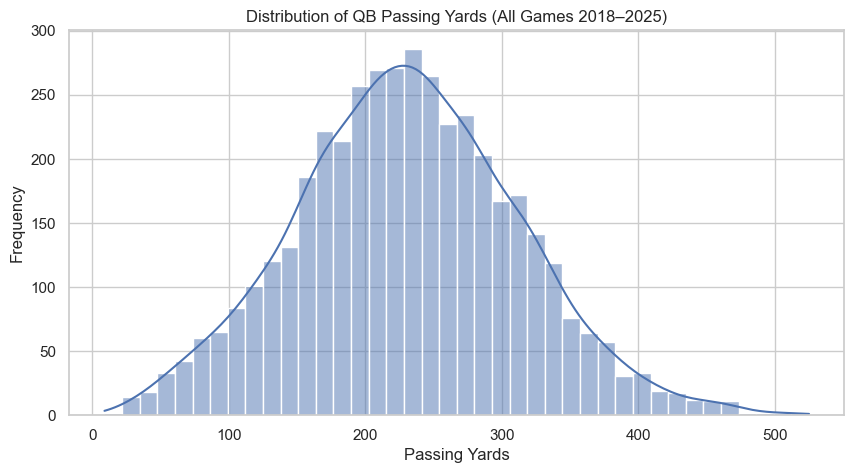

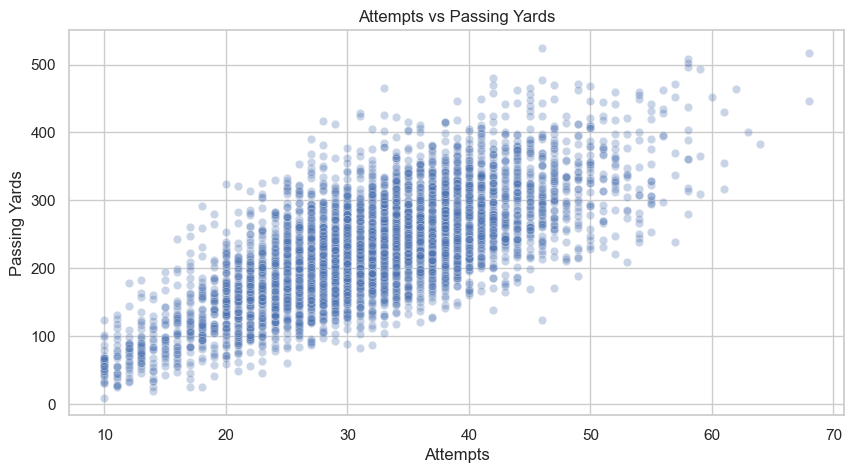

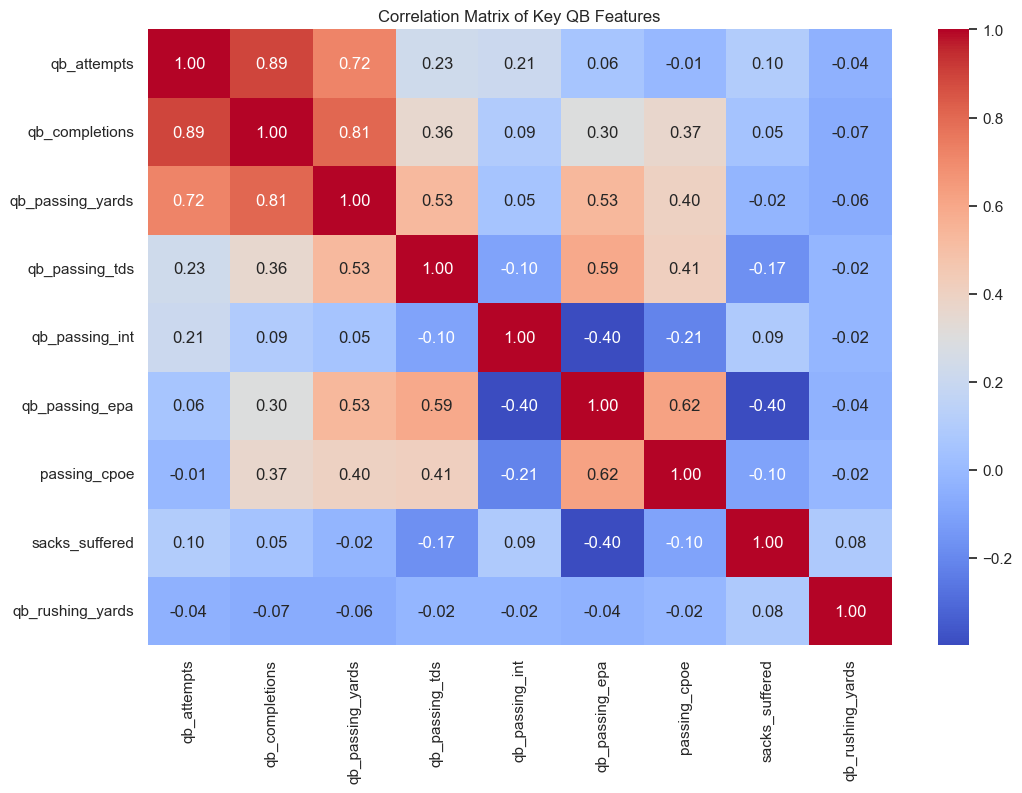

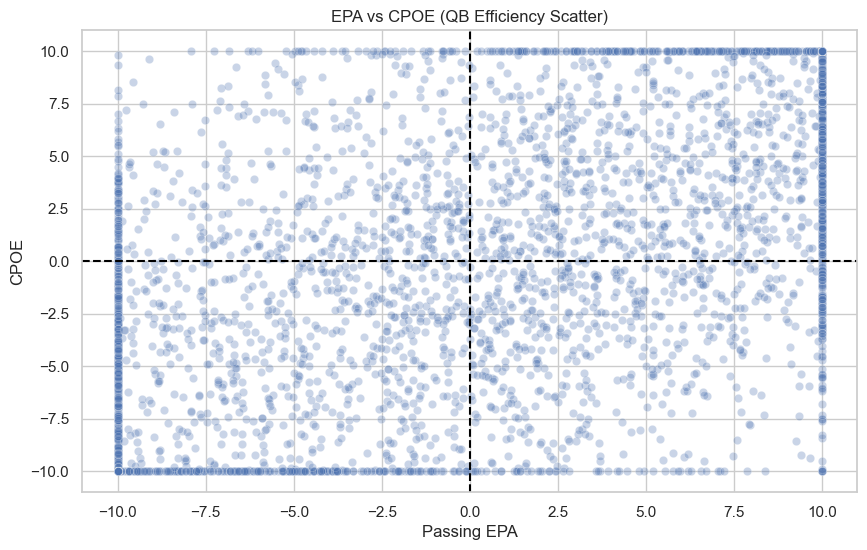

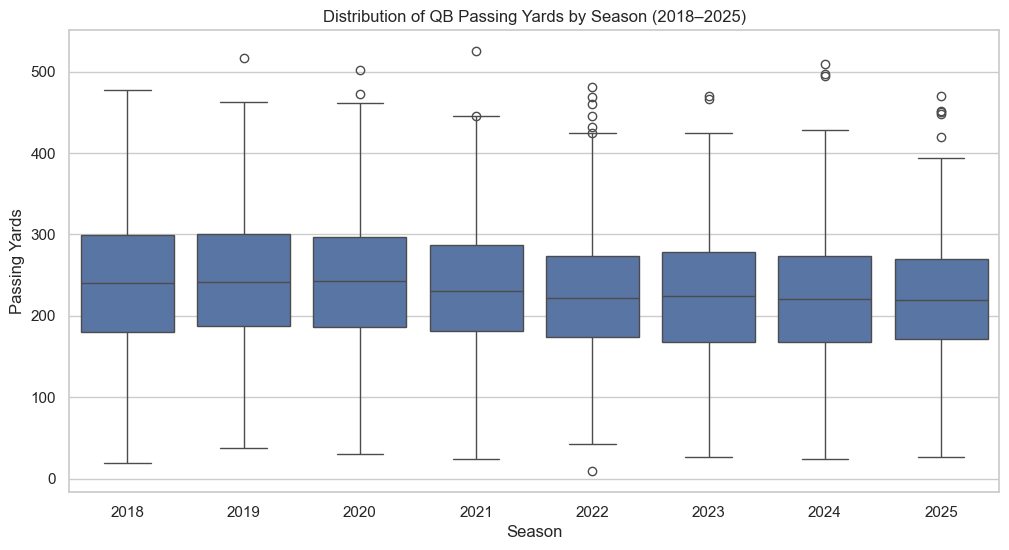

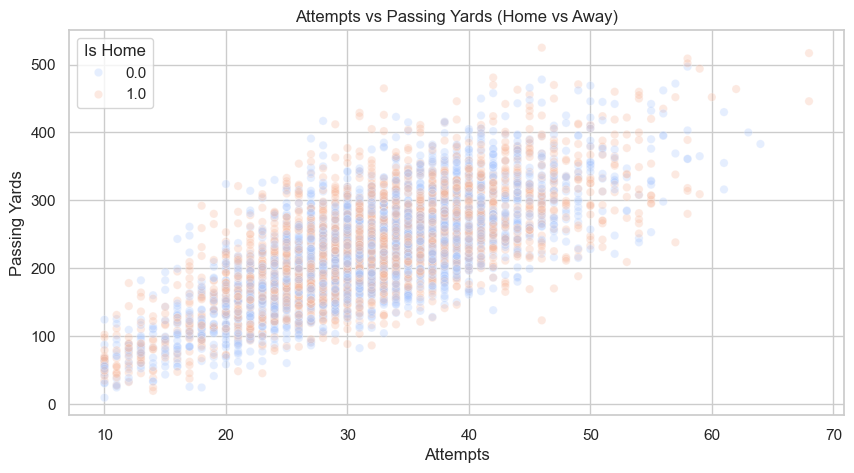

In [391]:
# EDA VISUALIZATIONS SECTION

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# distribution of passing yards
plt.figure(figsize=(10,5))
sns.histplot(qbs_merged["qb_passing_yards"], bins=40, kde=True)
plt.title("Distribution of QB Passing Yards (All Games 2018–2025)")
plt.xlabel("Passing Yards")
plt.ylabel("Frequency")
plt.show()

# scatter of attempts vs yards
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=qbs_merged["qb_attempts"],
    y=qbs_merged["qb_passing_yards"],
    alpha=0.3
)
plt.title("Attempts vs Passing Yards")
plt.xlabel("Attempts")
plt.ylabel("Passing Yards")
plt.show()

# correlation heatmap
corr_cols = [
    "qb_attempts", "qb_completions", "qb_passing_yards",
    "qb_passing_tds", "qb_passing_int",
    "qb_passing_epa", "passing_cpoe",
    "sacks_suffered", "qb_rushing_yards"
]

corr_matrix = qbs_merged[corr_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Key QB Features")
plt.show()

# epa vs cpoe
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=qbs_merged,
    x="qb_passing_epa",
    y="passing_cpoe",
    alpha=0.3
)
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.title("EPA vs CPOE (QB Efficiency Scatter)")
plt.xlabel("Passing EPA")
plt.ylabel("CPOE")
plt.show()

# passing yards distribution
plt.figure(figsize=(12,6))
sns.boxplot(
    data=qbs_merged,
    x="season",
    y="qb_passing_yards"
)
plt.title("Distribution of QB Passing Yards by Season (2018–2025)")
plt.xlabel("Season")
plt.ylabel("Passing Yards")
plt.show()


# attempts vs yards home/away
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=qbs_merged,
    x="qb_attempts",
    y="qb_passing_yards",
    hue="is_home",
    alpha=0.3,
    palette="coolwarm"
)
plt.title("Attempts vs Passing Yards (Home vs Away)")
plt.xlabel("Attempts")
plt.ylabel("Passing Yards")
plt.legend(title="Is Home")
plt.show()

In [392]:
# 10. RANDOM FOREST BASELINE (YARDS)

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_mse  = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, rf_preds)

print("RandomForest Performance (2025, Yards):")
print("MAE:  ", rf_mae)
print("RMSE: ", rf_rmse)
print("R²:   ", rf_r2)

# feature importance top 20
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = rf_importances.sort_values(ascending=False).head(20)
print("Top 20 Feature Importance:")
print(top20)

test_rows = qbs_merged.loc[X_test.index]

results_2025 = pd.DataFrame({
    'player_name': test_rows['player_name'],
    'team':        test_rows['team'],
    'week':        test_rows['week'],
    'actual_passing_yards': y_test.values,
    'predicted_passing_yards': rf_preds
})

results_2025['predicted_passing_yards'] = results_2025['predicted_passing_yards'].round(1)
results_2025 = results_2025.sort_values(['team', 'week']).reset_index(drop=True)

RandomForest Performance (2025, Yards):
MAE:   46.98468602431558
RMSE:  58.45513290516164
R²:    0.38375680932121403
Top 20 Feature Importance:
qb_passing_epa                  0.232379
team_passing_epa                0.145528
passing_cpoe                    0.065509
qb_passing_yards_season         0.021667
qb_rushing_epa                  0.017041
opp_def_sacks                   0.016842
team_rushing_epa                0.016460
qb_passing_yards_5              0.014178
qb_completions_season           0.009239
qb_rushing_epa_5                0.008418
qb_passing_epa_5                0.008367
qb_rushing_epa_3                0.008252
rushing_epa_3                   0.008249
passing_yards_5                 0.008207
qb_rushing_epa_season           0.008204
passing_first_downs_season      0.008162
qb_passing_yards_3              0.007956
qb_attempts_season              0.007835
opp_def_pass_defended_season    0.007671
opp_penalty_yards_season        0.007160
dtype: float64


In [393]:
# 11. XGBOOST MODEL (YARDS)

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2   = r2_score(y_test, xgb_preds)

print("\nXGBoost Performance (2025, Yards):")
print("MAE:  ", xgb_mae)
print("RMSE: ", xgb_rmse)
print("R²:   ", xgb_r2)


XGBoost Performance (2025, Yards):
MAE:   47.43718719482422
RMSE:  59.042022739899
R²:    0.3713204860687256


In [394]:
# 12. LIGHTGBM MODEL (YARDS)

lgb = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, y_train)
lgb_preds = lgb.predict(X_test)

lgb_mae  = mean_absolute_error(y_test, lgb_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_r2   = r2_score(y_test, lgb_preds)

print("\nLightGBM Performance (2025, Yards):")
print("MAE:  ", lgb_mae)
print("RMSE: ", lgb_rmse)
print("R²:   ", lgb_r2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15125
[LightGBM] [Info] Number of data points in the train set: 3844, number of used features: 97
[LightGBM] [Info] Start training from score 232.263007

LightGBM Performance (2025, Yards):
MAE:   46.894652912169356
RMSE:  57.772608683577474
R²:    0.39806335205398


In [395]:
# 13. MODEL COMPARISON (YARDS)

comparison = pd.DataFrame({
    'Model': ['RandomForest', 'XGBoost', 'LightGBM'],
    'MAE':  [rf_mae, xgb_mae, lgb_mae],
    'RMSE': [rf_rmse, xgb_rmse, lgb_rmse],
    'R²':   [rf_r2, xgb_r2, lgb_r2]
})

print("\n\n========= MODEL COMPARISON (YARDS) =========")
print(comparison)



========= MODEL COMPARISON (YARDS) =========
          Model        MAE       RMSE        R²
0  RandomForest  46.984686  58.455133  0.383757
1       XGBoost  47.437187  59.042023  0.371320
2      LightGBM  46.894653  57.772609  0.398063


In [396]:
# PREVIEW: ACTUAL vs PREDICTED PASSING YARDS (2025 WEEKS 1–12)

# we'll use random forest predictions
preds = rf_preds

preview_df = pd.DataFrame({
    "player_name": qbs_merged.loc[X_test.index, "player_name"].values,
    "team":        qbs_merged.loc[X_test.index, "team"].values,
    "week":        qbs_merged.loc[X_test.index, "week"].values,
    "actual_yards": y_test.values,
    "predicted_yards": preds
})

preview_df["predicted_yards"] = preview_df["predicted_yards"].round(1)

# Sort nicely
preview_df = preview_df.sort_values(["team", "week"]).reset_index(drop=True)

print("\n===== ACTUAL vs PREDICTED PASSING YARDS (2025 Weeks 1–12) =====")
print(preview_df.head(30))  # print first 30 rows, adjust as needed


===== ACTUAL vs PREDICTED PASSING YARDS (2025 Weeks 1–12) =====
   player_name team  week  actual_yards  predicted_yards
0     K.Murray  ARI     1           163            246.8
1     K.Murray  ARI     2           220            240.1
2     K.Murray  ARI     3           159            208.4
3     K.Murray  ARI     4           200            205.0
4     K.Murray  ARI     5           220            214.4
5   J.Brissett  ARI     6           320            242.3
6   J.Brissett  ARI     7           279            243.7
7   J.Brissett  ARI     9           261            263.1
8   J.Brissett  ARI    10           258            216.4
9   J.Brissett  ARI    11           452            252.7
10  J.Brissett  ARI    12           317            238.4
11  J.Brissett  ARI    13           301            273.8
12     M.Penix  ATL     1           298            262.3
13     M.Penix  ATL     2           135            230.2
14     M.Penix  ATL     3           172            142.3
15     M.Penix  ATL    

In [397]:
# PREVIEW: CLOSEST PREDICTIONS (Top 20 Lowest Error)

preds = rf_preds

preview_df = pd.DataFrame({
    "player_name": qbs_merged.loc[X_test.index, "player_name"].values,
    "team":        qbs_merged.loc[X_test.index, "team"].values,
    "week":        qbs_merged.loc[X_test.index, "week"].values,
    "actual_yards": y_test.values,
    "predicted_yards": preds
})

preview_df["predicted_yards"] = preview_df["predicted_yards"].round(1)
preview_df["abs_error"] = (preview_df["predicted_yards"] - preview_df["actual_yards"]).abs()

closest_df = preview_df.sort_values("abs_error").head(20).reset_index(drop=True)

print("\n===== TOP 20 CLOSEST PREDICTIONS=====")
print(closest_df)


===== TOP 20 CLOSEST PREDICTIONS=====
     player_name team  week  actual_yards  predicted_yards  abs_error
0      K.Cousins  ATL    13           234            233.9        0.1
1     M.Stafford   LA    12           273            272.6        0.4
2          B.Nix  DEN     5           242            241.5        0.5
3         C.Ward  TEN     2           175            175.6        0.6
4   T.Tagovailoa  MIA     6           205            206.2        1.2
5      S.Rattler   NO     6           227            228.3        1.3
6     J.Browning  CIN     2           241            239.6        1.4
7       C.Stroud  HOU     8           318            319.6        1.6
8     T.Lawrence  JAX     5           221            219.3        1.7
9      S.Rattler   NO     2           207            205.0        2.0
10     P.Mahomes   KC     8           299            297.0        2.0
11     L.Jackson  BAL    11           193            191.0        2.0
12    J.Brissett  ARI     9           261          

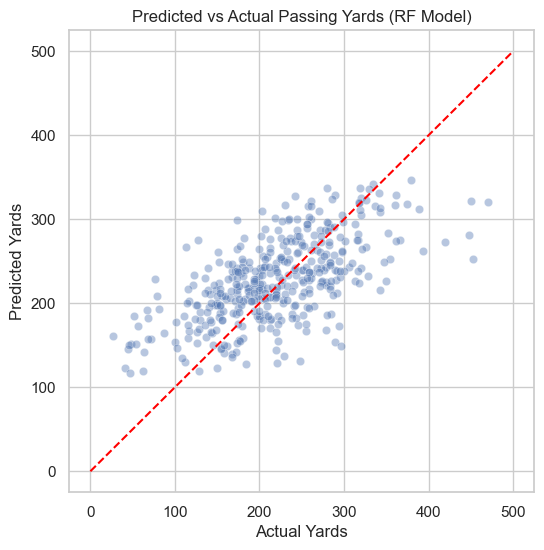

In [398]:
# model accuracy
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=rf_preds, alpha=0.4)
plt.xlabel("Actual Yards")
plt.ylabel("Predicted Yards")
plt.title("Predicted vs Actual Passing Yards (RF Model)")
plt.plot([0,500],[0,500], '--', color='red')
plt.show()

In [399]:
# 14. BUILD qb1_2025 FROM DEPTH CHARTS

depth = nfl.load_depth_charts(seasons=2025).to_pandas()

depth_qb = depth[depth["pos_abb"] == "QB"]
depth_qb1 = depth_qb[depth_qb["pos_rank"] == 1]

depth_qb1_latest = (
    depth_qb1.sort_values(["team", "dt"], ascending=[True, False])
    .groupby("team")
    .first()
    .reset_index()
)

qb1_2025 = (
    depth_qb1_latest[["team", "player_name", "gsis_id"]]
    .rename(columns={"gsis_id": "player_id"})
    .sort_values("team")
    .reset_index(drop=True)
)

print("qb1_2025 with player_id:")
print(qb1_2025.head(10))

qb1_2025 with player_id:
  team      player_name   player_id
0  ARI  Jacoby Brissett  00-0033119
1  ATL     Kirk Cousins  00-0029604
2  BAL    Lamar Jackson  00-0034796
3  BUF       Josh Allen  00-0034857
4  CAR      Bryce Young  00-0039150
5  CHI   Caleb Williams  00-0039918
6  CIN       Joe Burrow  00-0036442
7  CLE  Shedeur Sanders  00-0040668
8  DAL     Dak Prescott  00-0033077
9  DEN           Bo Nix  00-0039732


In [400]:
# 15. TRAIN FINAL XGBOOST MODELS ON COMPLETED GAMES (UP TO 2025 WK 12)
# one model for yards, another for attempts, another for completions


completed_mask = (qbs_merged['season'] < 2025) | (
    (qbs_merged['season'] == 2025) &
    (qbs_merged['week'] <= 12)
)

X_train_final = X.loc[completed_mask]

# targets
y_yards_all      = qbs_merged['qb_passing_yards']
y_attempts_all   = qbs_merged['qb_attempts']
y_completions_all = qbs_merged['qb_completions']

y_train_yards_final      = y_yards_all[completed_mask]
y_train_attempts_final   = y_attempts_all[completed_mask]
y_train_completions_final = y_completions_all[completed_mask]

print("Final training data shape (features):", X_train_final.shape)
print("  Yards labels shape:      ", y_train_yards_final.shape)
print("  Attempts labels shape:   ", y_train_attempts_final.shape)
print("  Completions labels shape:", y_train_completions_final.shape)

# hyerparams
xgb_params = dict(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# yards model
xgb_final_yards = XGBRegressor(**xgb_params)
xgb_final_yards.fit(X_train_final, y_train_yards_final)

# attempts model
xgb_final_attempts = XGBRegressor(**xgb_params)
xgb_final_attempts.fit(X_train_final, y_train_attempts_final)

# completions model
xgb_final_completions = XGBRegressor(**xgb_params)
xgb_final_completions.fit(X_train_final, y_train_completions_final)

print("Trained final XGBoost models on games up to 2025 week 12")

Final training data shape (features): (4212, 97)
  Yards labels shape:       (4212,)
  Attempts labels shape:    (4212,)
  Completions labels shape: (4212,)
Trained final XGBoost models on games up to 2025 week 12


In [401]:
# 16. FUTURE SCHEDULE (2025 WEEKS 13–18)

sched_2025 = nfl.load_schedules(seasons=2025).to_pandas()

future_sched = sched_2025[
    (sched_2025["game_type"] == "REG") &
    (sched_2025["week"] >= 13) &
    (sched_2025["week"] <= 18)
][["week", "home_team", "away_team"]].reset_index(drop=True)

print("Future games found:", future_sched.shape)

# merge starting QBs in
future_sched = future_sched.merge(
    qb1_2025.rename(columns={"team": "home_team", "player_name": "home_qb"}),
    on="home_team", how="left"
)

future_sched = future_sched.merge(
    qb1_2025.rename(columns={"team": "away_team", "player_name": "away_qb"}),
    on="away_team", how="left"
)

Future games found: (94, 3)


In [402]:
# 17. EXPAND INTO QB ROWS 1 PER ROW

home_rows = pd.DataFrame({
    "season":        2025,
    "week":          future_sched["week"],
    "team":          future_sched["home_team"],
    "opponent_team": future_sched["away_team"],
    "player_name":   future_sched["home_qb"],
    "player_id":     future_sched["player_id_x"],
    "is_home":       1
})

away_rows = pd.DataFrame({
    "season":        2025,
    "week":          future_sched["week"],
    "team":          future_sched["away_team"],
    "opponent_team": future_sched["home_team"],
    "player_name":   future_sched["away_qb"],
    "player_id":     future_sched["player_id_y"],
    "is_home":       0
})

future_qb_rows = pd.concat([home_rows, away_rows]).reset_index(drop=True)

future_qb_rows = future_qb_rows.sort_values(
    ["week", "team", "is_home"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\nFUTURE QB ROWS (with player_id):")
print(future_qb_rows.head(5))


FUTURE QB ROWS (with player_id):
   season  week team opponent_team      player_name   player_id  is_home
0    2025    13  ARI            TB  Jacoby Brissett  00-0033119        0
1    2025    13  ATL           NYJ     Kirk Cousins  00-0029604        0
2    2025    13  BAL           CIN    Lamar Jackson  00-0034796        1
3    2025    13  BUF           PIT       Josh Allen  00-0034857        0
4    2025    13  CAR            LA      Bryce Young  00-0039150        1


In [403]:
# 18. BUILD MODEL-READY FUTURE FEATURE ROWS

PAST_CUTOFF = (qbs_merged["season"] < 2025) | (
    (qbs_merged["season"] == 2025) &
    (qbs_merged["week"] <= 12)
)

historical = qbs_merged[PAST_CUTOFF].copy()

feature_cols = list(X.columns)

opp_cols = [c for c in feature_cols if c.startswith("opp_")]
base_off_cols = [c for c in feature_cols if c not in opp_cols + ["is_home"]]

print("Total feature columns:", len(feature_cols))
print("Opponent-defense cols:", len(opp_cols))
print("Offensive / other cols:", len(base_off_cols))

# defensive snapshot
defense_snapshot = (
    historical
    .sort_values(["opponent_team", "season", "week"])
    .groupby("opponent_team")
    .tail(1)[["opponent_team"] + opp_cols]
    .rename(columns={"opponent_team": "def_team"})
    .reset_index(drop=True)
)

print("Defense snapshot shape:", defense_snapshot.shape)

# latest QB stats
latest_qb_stats = (
    historical
    .sort_values(["player_id", "season", "week"])
    .groupby("player_id")
    .tail(1)[["player_id"] + base_off_cols]
)

print("Latest QB stats shape:", latest_qb_stats.shape)

# merge QB + DEF into future rows
is_home_col = future_qb_rows["is_home"].astype(float)
future_feature_rows = future_qb_rows.drop(columns=["is_home"]).copy()

future_feature_rows = future_feature_rows.merge(
    latest_qb_stats,
    on="player_id",
    how="left"
)

future_feature_rows = future_feature_rows.merge(
    defense_snapshot,
    left_on="opponent_team",
    right_on="def_team",
    how="left"
)

future_feature_rows = future_feature_rows.drop(columns=["def_team"])
future_feature_rows["is_home"] = is_home_col

print("After merging QB + DEF features:", future_feature_rows.shape)

missing = [c for c in feature_cols if c not in future_feature_rows.columns]
print("Missing future columns:", missing)

X_future_final = future_feature_rows[feature_cols].copy()
print("Final feature matrix for future predictions:", X_future_final.shape)

Total feature columns: 97
Opponent-defense cols: 25
Offensive / other cols: 71
Defense snapshot shape: (32, 26)
Latest QB stats shape: (145, 72)
After merging QB + DEF features: (188, 103)
Missing future columns: []
Final feature matrix for future predictions: (188, 97)


In [404]:
# 19. PREDICT FUTURE WEEKS 13–18:
# PASSING YARDS, ATTEMPTS< COMPLECTIONS, COMP%, YPA

future_yards      = xgb_final_yards.predict(X_future_final)
future_attempts   = xgb_final_attempts.predict(X_future_final)
future_completions = xgb_final_completions.predict(X_future_final)

with np.errstate(divide='ignore', invalid='ignore'):
    safe_attempts = np.where(future_attempts <= 0, np.nan, future_attempts)
    future_comp_pct = (future_completions / safe_attempts) * 100.0
    future_ypa      = future_yards / safe_attempts

future_results = pd.DataFrame({
    "season":        future_qb_rows["season"],
    "week":          future_qb_rows["week"],
    "team":          future_qb_rows["team"],
    "opponent_team": future_qb_rows["opponent_team"],
    "player_name":   future_qb_rows["player_name"],
    "player_id":     future_qb_rows["player_id"],
    "is_home":       future_qb_rows["is_home"].astype(int),

    "predicted_attempts":      np.round(future_attempts, 1),
    "predicted_completions":   np.round(future_completions, 1),
    "predicted_passing_yards": np.round(future_yards, 1),
    "predicted_comp_pct":      np.round(future_comp_pct, 1),
    "predicted_ypa":           np.round(future_ypa, 2),
})

future_results = future_results.sort_values(["week", "team"]).reset_index(drop=True)

# example - Week 13 predictions
week13_preds = future_results[future_results["week"] == 13]
print("\nWeek 13 predictions (Attempts / Completions / Yards):")
print(week13_preds)


Week 13 predictions (Attempts / Completions / Yards):
    season  week team opponent_team       player_name   player_id  is_home  predicted_attempts  predicted_completions  predicted_passing_yards  predicted_comp_pct  predicted_ypa
0     2025    13  ARI            TB   Jacoby Brissett  00-0033119        0           39.799999              29.000000               238.300003           72.699997           5.98
1     2025    13  ATL           NYJ      Kirk Cousins  00-0029604        0           25.299999              17.400000               208.699997           68.599998           8.24
2     2025    13  BAL           CIN     Lamar Jackson  00-0034796        1           25.299999              15.900000               186.300003           63.000000           7.38
3     2025    13  BUF           PIT        Josh Allen  00-0034857        0           33.900002              23.200001               230.199997           68.500000           6.78
4     2025    13  CAR            LA       Bryce Young  

In [405]:
# 20. DEBUG & HELPERS

# Feature importances (full)
rf_importances_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n===== TOP 40 FEATURES (RF) =====")
print(rf_importances_df.head(40))


def inspect_features(player_name, week, future=True):
    """
    Inspect model input features for a given player & week.
    """
    df = future_feature_rows if future else qbs_merged

    rows = df[(df["player_name"] == player_name) & (df["week"] == week)]
    if rows.empty:
        print("No matching row found.")
        return

    cols = list(X_train.columns)
    feature_row = rows[cols].iloc[0]

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 3000)

    return feature_row.to_frame(name=f"{player_name} - Week {week}")


print("\nExample inspect: Baker Mayfield Week 13 future features")
print(inspect_features("Baker Mayfield", 13))

# exampke: Baker Mayfield historical season
baker_hist = qbs_merged[
    (qbs_merged.player_id == "00-0034855") &
    (qbs_merged.season == 2025) &
    (qbs_merged.week <= 12)
][["week", "qb_passing_yards", "qb_passing_epa", "passing_cpoe"]].sort_values("week")

print("\nBaker Mayfield 2025 weeks 1–12 (hist):")
print(baker_hist)


===== TOP 40 FEATURES (RF) =====
                            feature  importance
0                    qb_passing_epa    0.232379
28                 team_passing_epa    0.145528
1                      passing_cpoe    0.065509
72          qb_passing_yards_season    0.021667
2                    qb_rushing_epa    0.017041
3                     opp_def_sacks    0.016842
29                 team_rushing_epa    0.016460
71               qb_passing_yards_5    0.014178
69            qb_completions_season    0.009239
92                 qb_rushing_epa_5    0.008418
80                 qb_passing_epa_5    0.008367
91                 qb_rushing_epa_3    0.008252
60                    rushing_epa_3    0.008249
37                  passing_yards_5    0.008207
93            qb_rushing_epa_season    0.008204
50       passing_first_downs_season    0.008162
70               qb_passing_yards_3    0.007956
66               qb_attempts_season    0.007835
15     opp_def_pass_defended_season    0.007671
27    

In [406]:
# 21. FUNCTIONS FOR LOOKUP

def qb_future_weeks(player_name):
    """
    Return all future predictions (weeks 13–18) for the given QB.
    """
    rows = future_results[future_results["player_name"] == player_name]
    if rows.empty:
        return f"No future predictions found for {player_name}."
    return rows.reset_index(drop=True)


def qb_week(player_name, week):
    """
    Return the prediction row for a given QB + week.
    """
    rows = future_results[
        (future_results["player_name"] == player_name) &
        (future_results["week"] == week)
    ]
    if rows.empty:
        return f"No prediction found for {player_name} in week {week}."
    return rows.reset_index(drop=True)


def week_all_qbs(week):
    """
    Return predictions for ALL QBs (both teams) for the specified week.
    """
    rows = future_results[future_results["week"] == week]
    if rows.empty:
        return f"No predictions found for week {week}."
    return rows.sort_values("team").reset_index(drop=True)

In [407]:
qb_future_weeks("Dak Prescott")

,season,week,team,opponent_team,player_name,player_id,is_home,predicted_attempts,predicted_completions,predicted_passing_yards,predicted_comp_pct,predicted_ypa
0,2025,13,DAL,KC,Dak Prescott,00-0033077,1,35.900002,24.600000,275.399994,68.599998,7.68
1,2025,14,DAL,DET,Dak Prescott,00-0033077,0,37.099998,23.600000,284.799988,63.500000,7.67
2,2025,15,DAL,MIN,Dak Prescott,00-0033077,1,33.700001,21.900000,284.500000,65.000000,8.44
3,2025,16,DAL,LAC,Dak Prescott,00-0033077,1,36.099998,24.500000,279.799988,67.800003,7.74
4,2025,17,DAL,WAS,Dak Prescott,00-0033077,0,37.200001,24.799999,313.500000,66.500000,8.42
5,2025,18,DAL,NYG,Dak Prescott,00-0033077,0,37.500000,24.500000,310.899994,65.500000,8.30
